In [1]:
import xarray as xr

# Open all AGCD monthly precipitation files (AGCD v2.0.3)
ds = xr.open_mfdataset(
    "/g/data/zv2/agcd/v2-0-3/precip/total/r005/01month/agcd_v2_precip_total_r005_monthly_*.nc",
    combine="by_coords",
    chunks={"time": 120}
)

# Check the available period
print("Input start:", ds.time.min().values)
print("Input end  :", ds.time.max().values)

# Calculate 12-month rolling mean on the FULL dataset
precip_12m = ds["precip"].rolling(
    time=12,
    min_periods=12
).mean()

# Select Jan 1940 to Dec 2023
precip_12m = precip_12m.sel(
    time=slice("1940-01-01", "2023-12-31")
)

# Rename the variable
precip_12m = precip_12m.rename("precip_12m")

# Check the output
print(precip_12m)
print("Output start:", precip_12m.time.min().values)
print("Output end  :", precip_12m.time.max().values)

# Example: view values at a grid cell
ts = precip_12m.sel(
    lat=-42.9,
    lon=147.3,
    method="nearest"
)

print(ts.isel(time=slice(0, 20)).compute())

/jobfs/171422796.gadi-pbs/ipykernel_3404367/2192677434.py:4: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(


Input start: 1900-01-16T00:00:00.000000000
Input end  : 2024-12-16T00:00:00.000000000
<xarray.DataArray 'precip_12m' (time: 1008, lat: 691, lon: 886)> Size: 2GB
dask.array<getitem, shape=(1008, 691, 886), dtype=float32, chunksize=(12, 691, 886), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 8kB 1940-01-16 1940-02-15 ... 2023-12-16
  * lat      (lat) float32 3kB -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon      (lon) float32 4kB 112.0 112.1 112.1 112.2 ... 156.1 156.2 156.2
Attributes:
    cell_methods:           time: sum time: sum (interval : 1 day)
    units:                  mm
    long_name:              Daily precipitation
    standard_name:          lwe_thickness_of_precipitation_amount
    frequency:              monthly
    start_offset:           -24
    grid_mapping:           crs
    coverage_content_type:  physicalMeasurement
    valid_range:            [     0. 100000.]
Output start: 1940-01-16T00:00:00.000000000
Output end  : 2023-12

In [2]:
print(precip_12m.shape)

(1008, 691, 886)


In [3]:
import xarray as xr

# Select cool season months: May (5) to October (10)
cool = precip_12m.sel(
    time=precip_12m.time.dt.month.isin([5, 6, 7, 8, 9, 10])
)

print(cool)

<xarray.DataArray 'precip_12m' (time: 504, lat: 691, lon: 886)> Size: 1GB
dask.array<getitem, shape=(504, 691, 886), dtype=float32, chunksize=(12, 691, 886), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 4kB 1940-05-16 ... 2023-10-16
  * lat      (lat) float32 3kB -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon      (lon) float32 4kB 112.0 112.1 112.1 112.2 ... 156.1 156.2 156.2
Attributes:
    cell_methods:           time: sum time: sum (interval : 1 day)
    units:                  mm
    long_name:              Daily precipitation
    standard_name:          lwe_thickness_of_precipitation_amount
    frequency:              monthly
    start_offset:           -24
    grid_mapping:           crs
    coverage_content_type:  physicalMeasurement
    valid_range:            [     0. 100000.]


In [4]:
cool_p25 = cool.quantile(
    0.25,
    dim="time"
)

cool_p25 = cool_p25.rename("cool_p25")

print(cool_p25)

<xarray.DataArray 'cool_p25' (lat: 691, lon: 886)> Size: 5MB
dask.array<getitem, shape=(691, 886), dtype=float64, chunksize=(227, 292), chunktype=numpy.ndarray>
Coordinates:
  * lat       (lat) float32 3kB -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon       (lon) float32 4kB 112.0 112.1 112.1 112.2 ... 156.1 156.2 156.2
    quantile  float64 8B 0.25
Attributes:
    cell_methods:           time: sum time: sum (interval : 1 day)
    units:                  mm
    long_name:              Daily precipitation
    standard_name:          lwe_thickness_of_precipitation_amount
    frequency:              monthly
    start_offset:           -24
    grid_mapping:           crs
    coverage_content_type:  physicalMeasurement
    valid_range:            [     0. 100000.]


In [5]:
print(cool_p25.shape)

(691, 886)


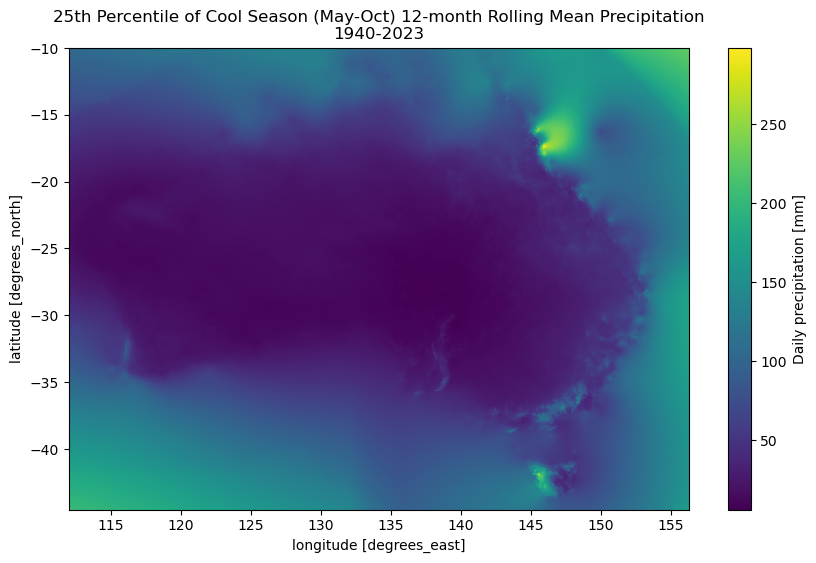

In [6]:
import matplotlib.pyplot as plt

cool_p25.plot(figsize=(10, 6))

plt.title("25th Percentile of Cool Season (May-Oct) 12-month Rolling Mean Precipitation\n1940-2023")
plt.show()

In [13]:
ts_1945 = precip_12m.sel(
    lat=-40,
    lon=148,
    method="nearest"
).sel(
    time=slice("1945-01-01", "1945-12-31")
)

print(ts_1945.compute())

<xarray.DataArray 'precip_12m' (time: 12)> Size: 48B
array([49.60246 , 58.405437, 57.280113, 53.873535, 48.60783 , 49.67798 ,
       47.51359 , 53.30697 , 55.101562, 58.625244, 58.01359 , 51.465576],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 96B 1945-01-16 ... 1945-12-16
    lat      float32 4B -40.0
    lon      float32 4B 148.0
Attributes:
    cell_methods:           time: sum time: sum (interval : 1 day)
    units:                  mm
    long_name:              Daily precipitation
    standard_name:          lwe_thickness_of_precipitation_amount
    frequency:              monthly
    start_offset:           -24
    grid_mapping:           crs
    coverage_content_type:  physicalMeasurement
    valid_range:            [     0. 100000.]


In [12]:
p25 = cool_p25.sel(
    lat=-40,
    lon=148,
    method="nearest"
)

print(p25.compute())

<xarray.DataArray 'cool_p25' ()> Size: 8B
array(57.00527096)
Coordinates:
    lat       float32 4B -40.0
    lon       float32 4B 148.0
    quantile  float64 8B 0.25
Attributes:
    cell_methods:           time: sum time: sum (interval : 1 day)
    units:                  mm
    long_name:              Daily precipitation
    standard_name:          lwe_thickness_of_precipitation_amount
    frequency:              monthly
    start_offset:           -24
    grid_mapping:           crs
    coverage_content_type:  physicalMeasurement
    valid_range:            [     0. 100000.]


In [14]:
fig = plt.figure(figsize=(10, 8))

ax = plt.axes(projection=ccrs.PlateCarree())

cool_p25.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=20,
    cmap="YlOrRd",
    cbar_kwargs={"label": "25th percentile rainfall (mm)"}
)

ax.coastlines("10m")
ax.add_feature(states, edgecolor="black", linewidth=0.8)

ax.set_extent([112, 154, -44.5, -10])

plt.title(
    "Cool Season (May–Oct) 25th Percentile\n"
    "12-Month Rolling Mean Rainfall (1940–2023)"
)

plt.show()

NameError: name 'ccrs' is not defined

<Figure size 1000x800 with 0 Axes>

In [15]:
print(cool_p25)

# <xarray.DataArray 'cool_p25' (lat: 691, lon: 886)>

<xarray.DataArray 'cool_p25' (lat: 691, lon: 886)> Size: 5MB
dask.array<getitem, shape=(691, 886), dtype=float64, chunksize=(227, 292), chunktype=numpy.ndarray>
Coordinates:
  * lat       (lat) float32 3kB -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon       (lon) float32 4kB 112.0 112.1 112.1 112.2 ... 156.1 156.2 156.2
    quantile  float64 8B 0.25
Attributes:
    cell_methods:           time: sum time: sum (interval : 1 day)
    units:                  mm
    long_name:              Daily precipitation
    standard_name:          lwe_thickness_of_precipitation_amount
    frequency:              monthly
    start_offset:           -24
    grid_mapping:           crs
    coverage_content_type:  physicalMeasurement
    valid_range:            [     0. 100000.]


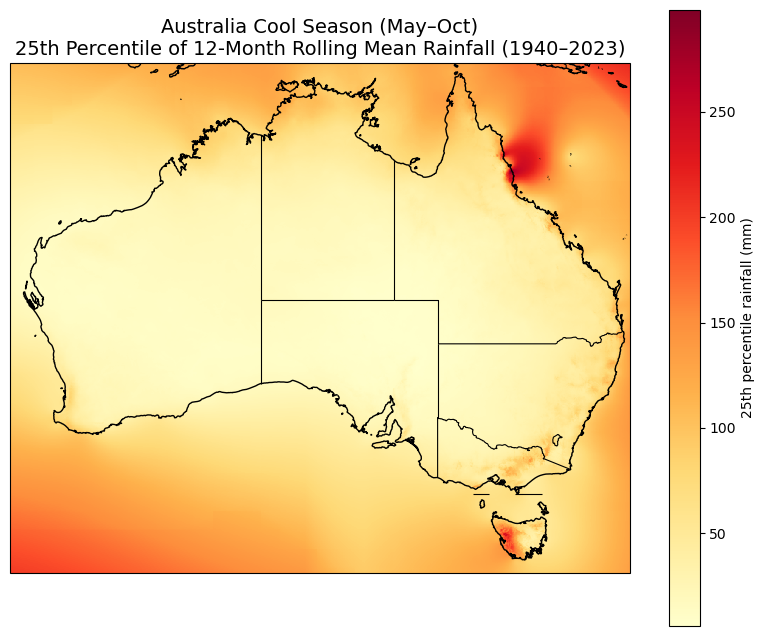

In [16]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Create figure
fig = plt.figure(figsize=(10, 8))

ax = plt.axes(projection=ccrs.PlateCarree())

# Plot the 25th percentile map
cool_p25.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="YlOrRd",
    cbar_kwargs={
        "label": "25th percentile rainfall (mm)"
    }
)

# Add coastlines and boundaries
ax.coastlines(resolution="10m", linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# Add state/province boundaries
states = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='10m',
    facecolor='none'
)

ax.add_feature(states, edgecolor='black', linewidth=0.8)

# Australia extent
ax.set_extent([112, 154, -44.5, -10], crs=ccrs.PlateCarree())

# Title
plt.title(
    "Australia Cool Season (May–Oct)\n"
    "25th Percentile of 12-Month Rolling Mean Rainfall (1940–2023)",
    fontsize=14
)

plt.show()

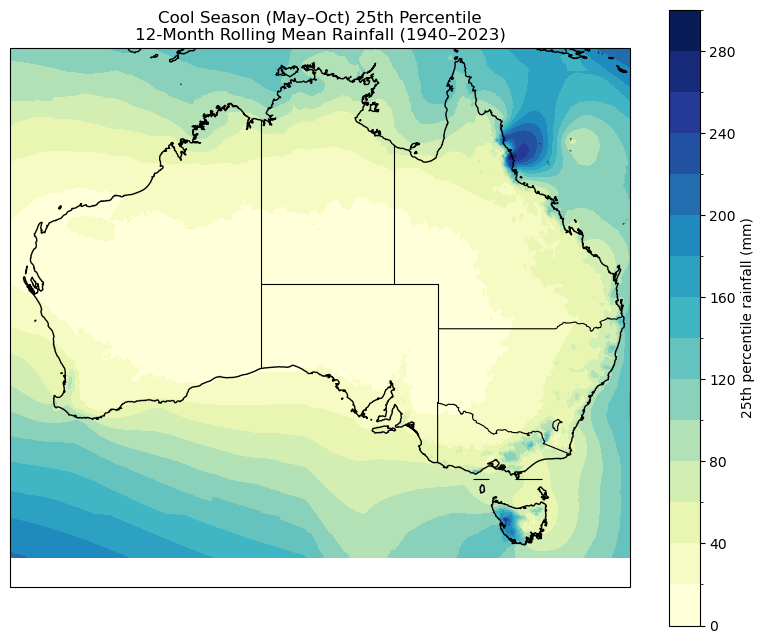

In [26]:
fig = plt.figure(figsize=(10, 8))

ax = plt.axes(projection=ccrs.PlateCarree())

cool_p25.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=20,
    cmap="YlGnBu",
    cbar_kwargs={"label": "25th percentile rainfall (mm)"}
)

ax.coastlines("10m")
ax.add_feature(states, edgecolor="black", linewidth=0.8)

ax.set_extent([112, 154, -44.5, -10])

plt.title(
    "Cool Season (May–Oct) 25th Percentile\n"
    "12-Month Rolling Mean Rainfall (1940–2023)"
)

plt.show()

In [27]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --------------------------------------------------
# Cool season (May-Oct)
# --------------------------------------------------

cool = precip_12m.sel(
    time=precip_12m.time.dt.month.isin([5,6,7,8,9,10])
)

print(cool.shape)
# (504, 691, 886)

# --------------------------------------------------
# 25th percentile threshold
# --------------------------------------------------

cool_p25 = cool.quantile(
    0.25,
    dim="time"
)

# --------------------------------------------------
# Drought mask
# --------------------------------------------------

drought = cool < cool_p25

# --------------------------------------------------
# Count drought months
# --------------------------------------------------

drought_count = drought.sum(dim="time")

print(drought_count)

# --------------------------------------------------
# Percentage drought months
# --------------------------------------------------

nmonths = cool.sizes["time"]

drought_percent = (
    drought_count / nmonths
) * 100

drought_percent = drought_percent.rename(
    "drought_percent"
)

print(drought_percent)

(504, 691, 886)
<xarray.DataArray 'precip_12m' (lat: 691, lon: 886)> Size: 5MB
dask.array<sum-aggregate, shape=(691, 886), dtype=int64, chunksize=(227, 292), chunktype=numpy.ndarray>
Coordinates:
  * lat       (lat) float32 3kB -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon       (lon) float32 4kB 112.0 112.1 112.1 112.2 ... 156.1 156.2 156.2
    quantile  float64 8B 0.25
Attributes:
    cell_methods:           time: sum time: sum (interval : 1 day)
    units:                  mm
    long_name:              Daily precipitation
    standard_name:          lwe_thickness_of_precipitation_amount
    frequency:              monthly
    start_offset:           -24
    grid_mapping:           crs
    coverage_content_type:  physicalMeasurement
    valid_range:            [     0. 100000.]
<xarray.DataArray 'drought_percent' (lat: 691, lon: 886)> Size: 5MB
dask.array<mul, shape=(691, 886), dtype=float64, chunksize=(227, 292), chunktype=numpy.ndarray>
Coordinates:
  * lat       (lat) 

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/dask/array/core.py:5198: PerformanceWarning: Increasing number of chunks by factor of 16
  result = blockwise(


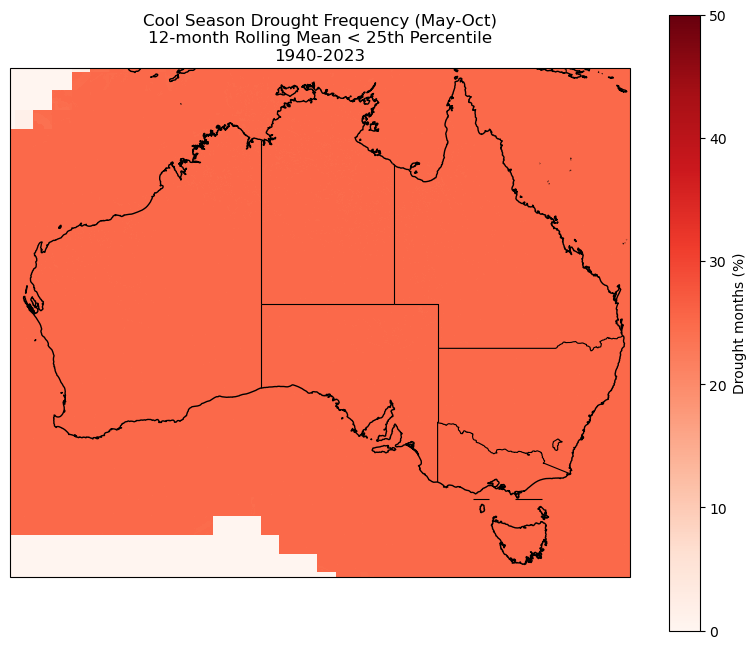

In [19]:
fig = plt.figure(figsize=(10,8))

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

drought_percent.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="Reds",
    vmin=0,
    vmax=50,
    cbar_kwargs={
        "label":"Drought months (%)"
    }
)

ax.coastlines("10m")

states = cfeature.NaturalEarthFeature(
    "cultural",
    "admin_1_states_provinces_lines",
    "10m",
    facecolor="none"
)

ax.add_feature(
    states,
    edgecolor="black",
    linewidth=0.8
)

ax.set_extent(
    [112,154,-44.5,-10],
    ccrs.PlateCarree()
)

plt.title(
    "Cool Season Drought Frequency (May-Oct)\n"
    "12-month Rolling Mean < 25th Percentile\n"
    "1940-2023"
)

plt.show()

In [20]:
# --------------------------------------------------
# Select cool season (May-Oct)
# --------------------------------------------------

cool = precip_12m.sel(
    time=precip_12m.time.dt.month.isin([5,6,7,8,9,10])
)

print(cool.shape)

# Expected:
# (504, 691, 886)

# --------------------------------------------------
# Calculate 25th percentile threshold
# --------------------------------------------------

cool_p25 = cool.quantile(
    0.25,
    dim="time"
)

print(cool_p25.shape)

# Expected:
# (691, 886)

# --------------------------------------------------
# Drought months
# --------------------------------------------------

drought = cool < cool_p25

print(drought)

# Expected:
# (504, 691, 886)
# dtype=bool

# --------------------------------------------------
# Count drought months
# --------------------------------------------------

drought_count = drought.sum(
    dim="time"
)

print(drought_count)

# Expected:
# (691,886)

# --------------------------------------------------
# Convert to percentage
# --------------------------------------------------

nmonths = cool.sizes["time"]

print("Total cool-season months =", nmonths)

drought_percent = (
    drought_count / nmonths
) * 100

drought_percent = drought_percent.rename(
    "drought_percent"
)

print(drought_percent)

(504, 691, 886)
(691, 886)
<xarray.DataArray 'precip_12m' (time: 504, lat: 691, lon: 886)> Size: 309MB
dask.array<lt, shape=(504, 691, 886), dtype=bool, chunksize=(12, 227, 292), chunktype=numpy.ndarray>
Coordinates:
  * time      (time) datetime64[ns] 4kB 1940-05-16 ... 2023-10-16
  * lat       (lat) float32 3kB -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon       (lon) float32 4kB 112.0 112.1 112.1 112.2 ... 156.1 156.2 156.2
    quantile  float64 8B 0.25
Attributes:
    cell_methods:           time: sum time: sum (interval : 1 day)
    units:                  mm
    long_name:              Daily precipitation
    standard_name:          lwe_thickness_of_precipitation_amount
    frequency:              monthly
    start_offset:           -24
    grid_mapping:           crs
    coverage_content_type:  physicalMeasurement
    valid_range:            [     0. 100000.]
<xarray.DataArray 'precip_12m' (lat: 691, lon: 886)> Size: 5MB
dask.array<sum-aggregate, shape=(691, 886), dty

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/dask/array/core.py:5198: PerformanceWarning: Increasing number of chunks by factor of 16
  result = blockwise(


In [21]:
print(
    drought_count.sel(
        lat=-35,
        lon=145,
        method="nearest"
    ).values
)

print(
    drought_percent.sel(
        lat=-35,
        lon=145,
        method="nearest"
    ).values
)

126
25.0


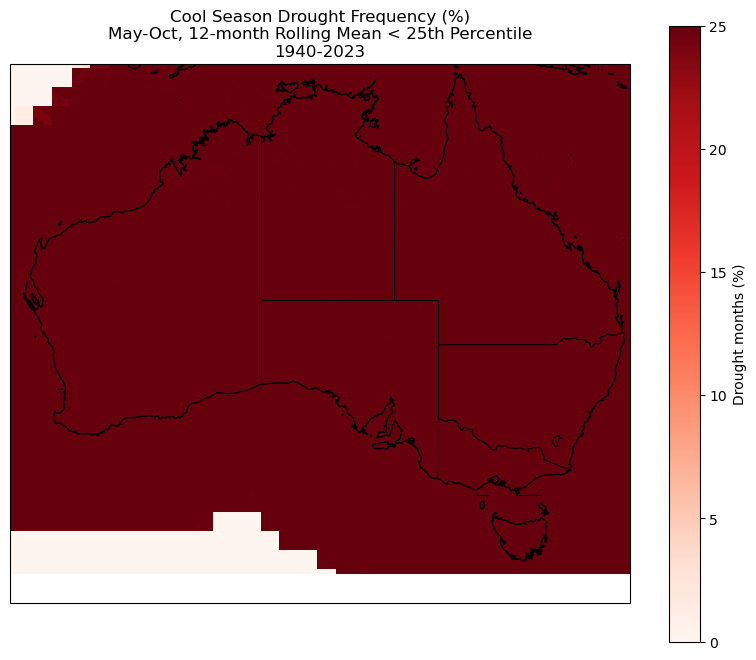

In [22]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10,8))

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

drought_percent.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="Reds",
    cbar_kwargs={
        "label":"Drought months (%)"
    }
)

ax.coastlines("10m")

states = cfeature.NaturalEarthFeature(
    category="cultural",
    name="admin_1_states_provinces_lines",
    scale="10m",
    facecolor="none"
)

ax.add_feature(
    states,
    edgecolor="black",
    linewidth=0.8
)

ax.set_extent(
    [112,154,-44.5,-10]
)

plt.title(
    "Cool Season Drought Frequency (%)\n"
    "May-Oct, 12-month Rolling Mean < 25th Percentile\n"
    "1940-2023"
)

plt.show()

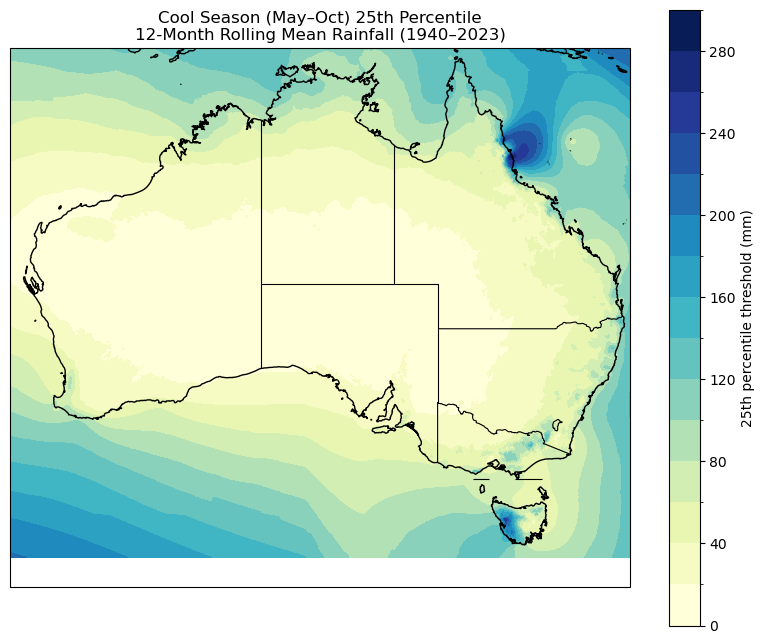

In [29]:
fig = plt.figure(figsize=(10, 8))

ax = plt.axes(projection=ccrs.PlateCarree())

cool_p25.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=20,
    cmap="YlGnBu",
    cbar_kwargs={"label": "25th percentile threshold (mm)"}
)

ax.coastlines("10m")
ax.add_feature(states, edgecolor="black", linewidth=0.8)

ax.set_extent([112, 154, -44.5, -10])

plt.title(
    "Cool Season (May–Oct) 25th Percentile\n"
    "12-Month Rolling Mean Rainfall (1940–2023)"
)

plt.show()

In [30]:
# Drought months (True/False)
drought = cool < cool_p25

# Count number of drought months
drought_count = drought.sum(dim="time")

print(drought_count)

<xarray.DataArray 'precip_12m' (lat: 691, lon: 886)> Size: 5MB
dask.array<sum-aggregate, shape=(691, 886), dtype=int64, chunksize=(227, 292), chunktype=numpy.ndarray>
Coordinates:
  * lat       (lat) float32 3kB -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon       (lon) float32 4kB 112.0 112.1 112.1 112.2 ... 156.1 156.2 156.2
    quantile  float64 8B 0.25
Attributes:
    cell_methods:           time: sum time: sum (interval : 1 day)
    units:                  mm
    long_name:              Daily precipitation
    standard_name:          lwe_thickness_of_precipitation_amount
    frequency:              monthly
    start_offset:           -24
    grid_mapping:           crs
    coverage_content_type:  physicalMeasurement
    valid_range:            [     0. 100000.]


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/dask/array/core.py:5198: PerformanceWarning: Increasing number of chunks by factor of 16
  result = blockwise(


In [31]:
print(
    drought_count.sel(
        lat=-35,
        lon=145,
        method="nearest"
    ).values
)

126


In [32]:
print("Minimum:", drought_count.min().compute().values)
print("Maximum:", drought_count.max().compute().values)
print("Mean   :", drought_count.mean().compute().values)

Minimum: 0
Maximum: 126
Mean   : 119.83870988817854


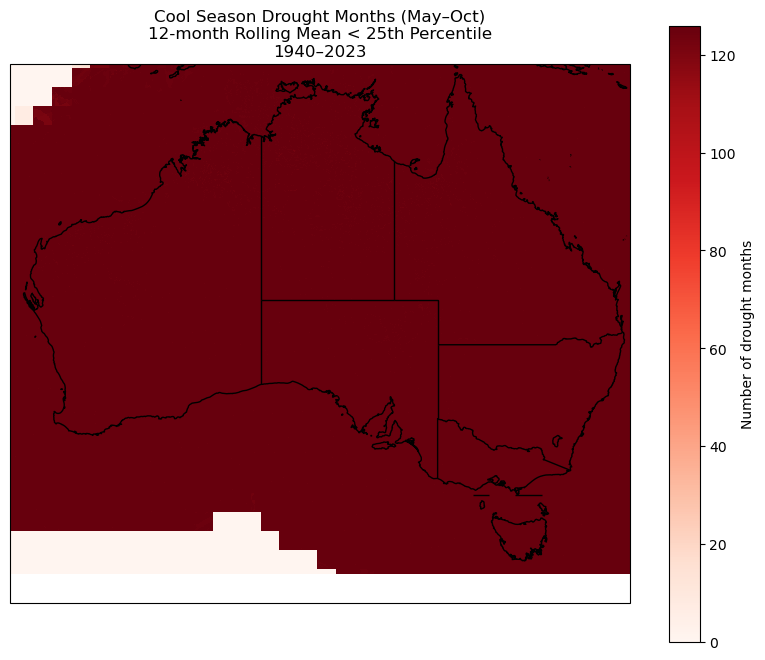

In [33]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10,8))

ax = plt.axes(projection=ccrs.PlateCarree())

drought_count.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="Reds",
    cbar_kwargs={
        "label": "Number of drought months"
    }
)

ax.coastlines("10m")

states = cfeature.NaturalEarthFeature(
    "cultural",
    "admin_1_states_provinces_lines",
    "10m",
    facecolor="none"
)

ax.add_feature(states, edgecolor="black")

ax.set_extent([112,154,-44.5,-10])

plt.title(
    "Cool Season Drought Months (May–Oct)\n"
    "12-month Rolling Mean < 25th Percentile\n"
    "1940–2023"
)

plt.show()